# FEATURE EXTRACTION AND VISUALIZATION

This notebook extracts HRV features from ECG signals and visualizes them
for different conditions (baseline, stress, amusement, meditation).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
sys.path.append('..')
warnings.filterwarnings('ignore')

# Import your classes
from src.data import Data
from src.features import Features
from src.visualization import Visualization

# Initialize classes
data_loader = Data(fs=700)
feature_extractor = Features(fs=700)
viz = Visualization()
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load data

In [ ]:
print("="*60)
print("2. LOADING DATA")
print("="*60)

# Load a single subject
pkl_path = "../data/WESAD/data/S2.pkl"
ecg, label = data_loader.read_subject(pkl_path)

print(f"✅ Loaded subject: S2")
print(f"   ECG shape: {ecg.shape}")
print(f"   Label shape: {label.shape}")
print(f"   Sampling frequency: {data_loader.fs} Hz")
print(f"   Total duration: {len(ecg)/data_loader.fs:.1f} seconds ({len(ecg)/data_loader.fs/60:.1f} minutes)")

1. LOADING DATA
✅ Loaded subject: S2
   ECG shape: (4255300,)
   Label shape: (4255300,)
   Sampling frequency: 700 Hz
   Total duration: 6079.0 seconds (101.3 minutes)


## 2. EXTRACT FEATURES FROM EACH CONDITION

In [ ]:
print("\n" + "="*60)
print("3. EXTRACTING HRV FEATURES BY CONDITION")
print("="*60)

# Label mapping
label_names = {
    1: "Baseline (Non-stress)",
    2: "Stress",
    3: "Amusement",
    4: "Meditation"
}

label_colors = {
    1: '#2d7a3e',  # Green
    2: '#c41e3a',  # Red
    3: '#4a90e2',  # Blue
    4: '#f5a623'   # Orange
}

# Extract 30-second chunks for each condition
features_by_condition = {}
chunk_duration = 30  # seconds

for label_id in [1, 2, 3, 4]:
    print(f"\nExtracting features for: {label_names[label_id]}")
    
    # Get ECG for this label
    ecg_condition = data_loader.get_label_sub(ecg, label, target_label=label_id)
    
    if len(ecg_condition) > 0:
        # Get chunks
        chunks = data_loader.get_chunked_ecg(ecg_condition, time_in_sec=chunk_duration)
        
        # Extract features from each chunk
        feature_list = []
        for chunk in chunks:
            features = feature_extractor.get_hrv_features(chunk)
            feature_list.append(features)
        
        # Convert to DataFrame
        df_features = pd.DataFrame(feature_list)
        df_features['condition'] = label_names[label_id]
        df_features['label_id'] = label_id
        features_by_condition[label_id] = df_features
        
        print(f"   ✓ Extracted {len(df_features)} feature vectors")
        print(f"   ✓ Shape: {df_features.shape}")
    else:
        print(f"   ✗ No data found for this condition")
        features_by_condition[label_id] = pd.DataFrame()

# Combine all features into one DataFrame
all_features_df = pd.concat([df for df in features_by_condition.values() if len(df) > 0], 
                            ignore_index=True)

print(f"\n✅ Total feature vectors: {len(all_features_df)}")


2. EXTRACTING HRV FEATURES BY CONDITION

Extracting features for: Baseline (Non-stress)
   ✓ Extracted 38 feature vectors
   ✓ Shape: (38, 10)

Extracting features for: Stress
   ✓ Extracted 20 feature vectors
   ✓ Shape: (20, 10)

Extracting features for: Amusement
   ✓ Extracted 12 feature vectors
   ✓ Shape: (12, 10)

Extracting features for: Meditation
   ✓ Extracted 25 feature vectors
   ✓ Shape: (25, 10)

✅ Total feature vectors: 95


## 3. FEATURE SUMMARY STATISTICS

In [6]:
print("\n" + "="*60)
print("3. FEATURE SUMMARY STATISTICS")
print("="*60)

# Feature columns
feature_cols = ['mean_rr', 'mean_hr', 'sdnn', 'rmssd', 'pnn50', 
                'lf_power', 'hf_power', 'lf_hf_ratio']

# Summary statistics by condition
summary_stats = all_features_df.groupby('condition')[feature_cols].agg(['mean', 'std', 'count'])
display(summary_stats.round(3))


3. FEATURE SUMMARY STATISTICS


mean_rr               mean_hr                 sdnn  \
                          mean     std count    mean    std count    mean   
condition                                                                   
Amusement              907.515  44.280    12  66.704  3.401    12  73.831   
Baseline (Non-stress)  828.266  35.807    38  73.050  3.552    38  62.218   
Meditation             893.519  37.788    25  67.729  3.034    25  67.897   
Stress                 781.004  38.014    20  77.521  4.027    20  59.771   

                                      rmssd  ... pnn50 lf_power            \
                          std count    mean  ... count     mean std count   
condition                                    ...                            
Amusement              13.423    12  81.606  ...    12      NaN NaN     0   
Baseline (Non-stress)  16.652    38  59.670  ...    38      NaN NaN     0   
Meditation             19.277    25  70.863  ...    25      NaN NaN     0   
Stress                 21.716    20  44.142  ...    20      NaN NaN     0   

                      hf_power           lf_hf_ratio            
                          mean std count        mean std count  
condition                                                       
Amusement                  NaN NaN     0         NaN NaN     0  
Baseline (Non-stress)      NaN NaN     0         NaN NaN     0  
Meditation                 NaN NaN     0         NaN NaN     0  
Stress                     NaN NaN     0         NaN NaN     0  

[4 rows x 24 columns]

## 4. VISUALIZE FEATURE DISTRIBUTIONS


4. FEATURE DISTRIBUTION PLOTS


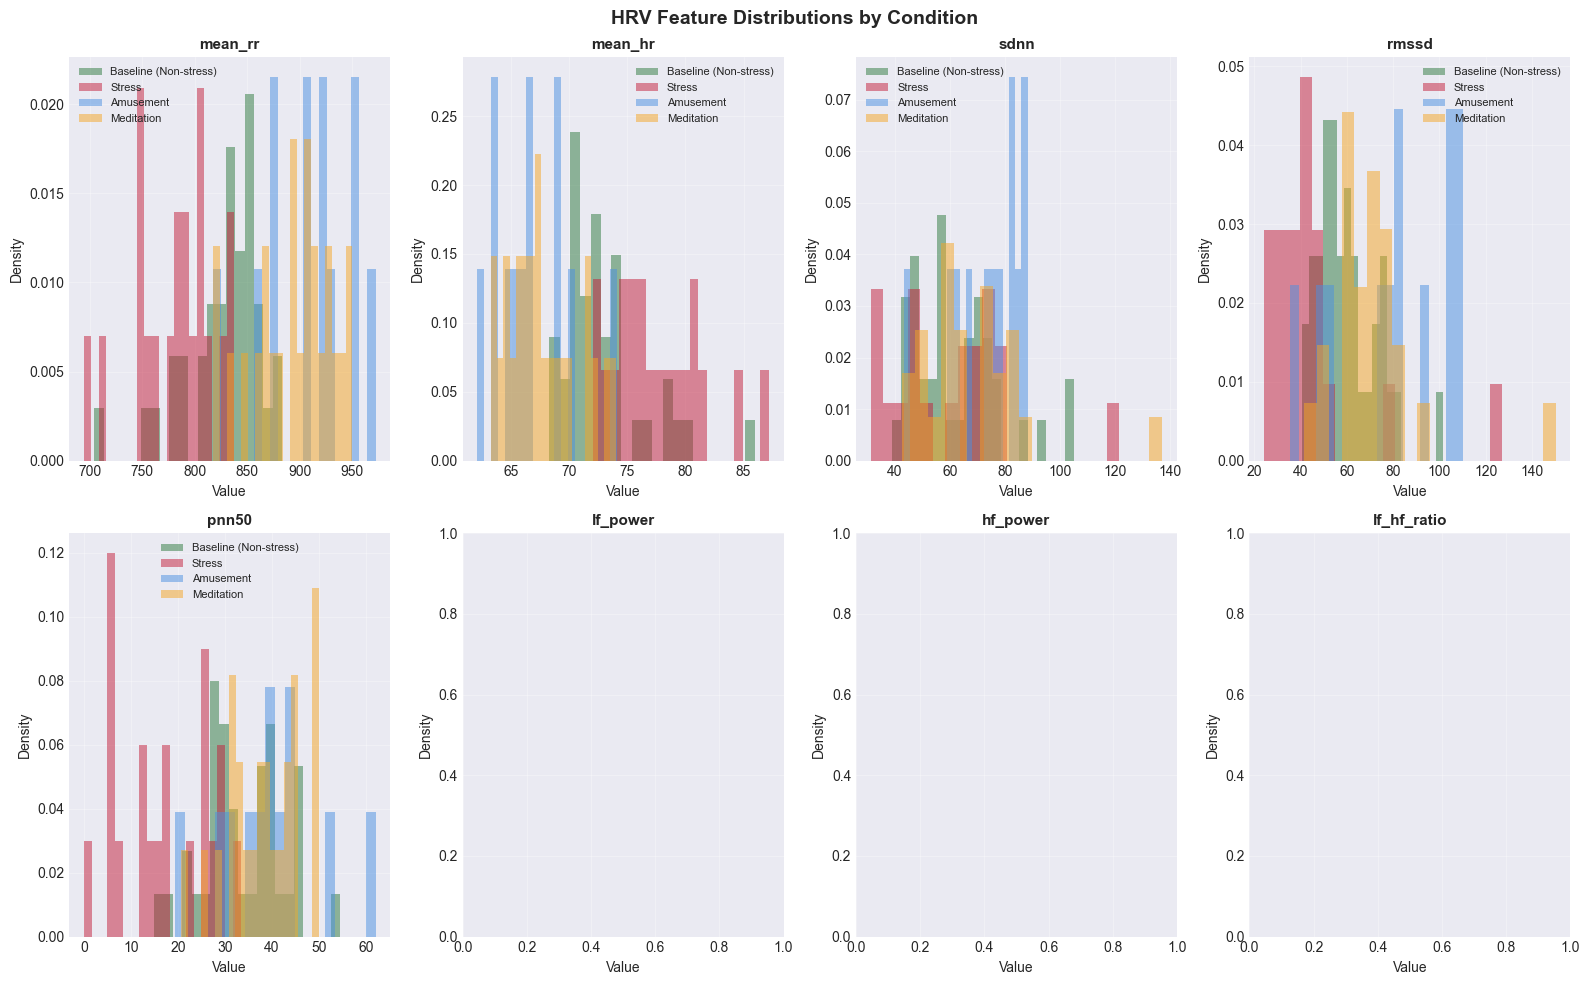

In [9]:
print("\n" + "="*60)
print("4. FEATURE DISTRIBUTION PLOTS")
print("="*60)

# Plot distributions for each feature
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    
    for label_id in [1, 2, 3, 4]:
        if label_id in features_by_condition and len(features_by_condition[label_id]) > 0:
            data = features_by_condition[label_id][feature].dropna()
            if len(data) > 0:
                ax.hist(data, bins=20, alpha=0.5, 
                       color=label_colors[label_id], 
                       label=label_names[label_id],
                       density=True)
    
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('HRV Feature Distributions by Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. BOX PLOTS FOR EACH FEATURE


5. BOX PLOTS COMPARING CONDITIONS


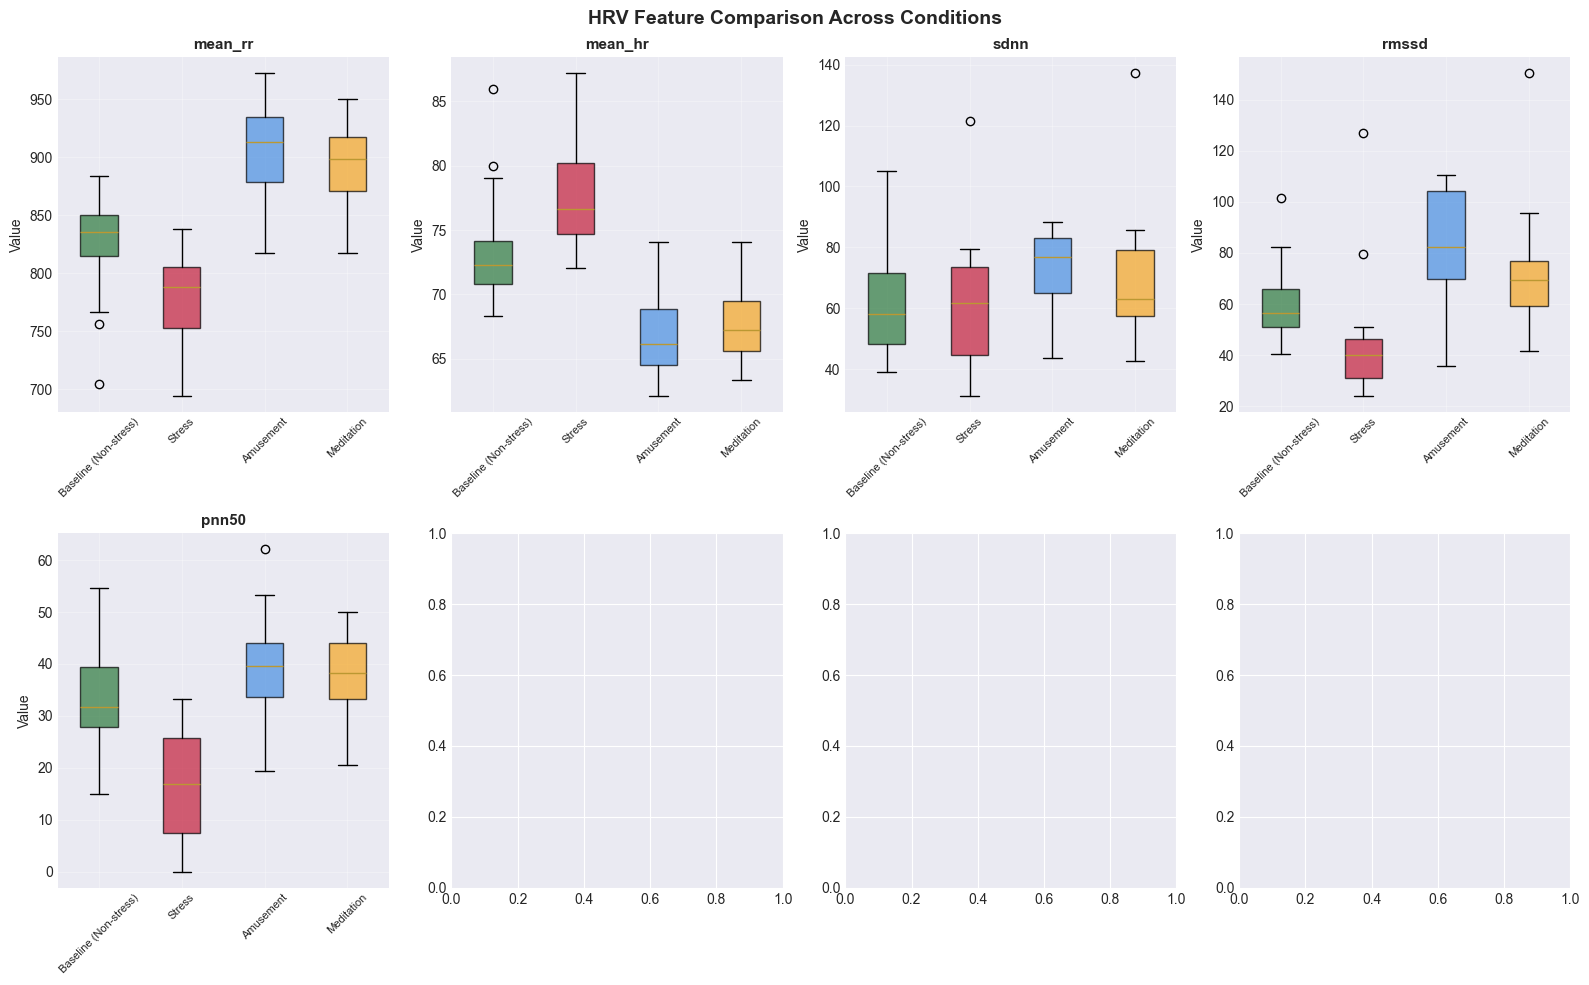

In [19]:
print("\n" + "="*60)
print("5. BOX PLOTS COMPARING CONDITIONS")
print("="*60)

# Create box plots for each feature
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    
    # Prepare data for box plot
    data_to_plot = []
    labels_to_plot = []
    
    for label_id in [1, 2, 3, 4]:
        if label_id in features_by_condition and len(features_by_condition[label_id]) > 0:
            data = features_by_condition[label_id][feature].dropna()
            if len(data) > 0:
                data_to_plot.append(data.values)  # Convert to array
                labels_to_plot.append(label_names[label_id])
    
    # Check if we have data to plot
    if len(data_to_plot) > 0:
        # Create box plot - FIX: use 'labels' as keyword argument
        bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)
        
        # Color the boxes
        for i, box in enumerate(bp['boxes']):
            if i < len(label_colors):
                # Get the label_id for this box
                label_id = [1, 2, 3, 4][i]
                box.set_facecolor(label_colors[label_id])
                box.set_alpha(0.7)
        
        ax.set_title(feature, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('HRV Feature Comparison Across Conditions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. CORRELATION MATRIX

In [21]:
print("\n" + "="*60)
print("6. FEATURE CORRELATION MATRIX (Table Format)")
print("="*60)

def display_correlation_table(df, feature_cols, title):
    """
    Display correlation matrix as a styled table
    """
    corr_matrix = df[feature_cols].corr()
    
    # Style the table
    styled = corr_matrix.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1)
    styled = styled.format("{:.2f}")
    styled = styled.set_caption(title)
    styled = styled.set_properties(**{
        'font-size': '12px',
        'text-align': 'center'
    })
    
    # Add color coding for correlations
    def color_cells(val):
        if val > 0.7:
            return 'background-color: #2d7a3e; color: white; font-weight: bold'
        elif val > 0.4:
            return 'background-color: #90c695; color: black'
        elif val > -0.4:
            return 'background-color: #f5f5f5; color: black'
        elif val > -0.7:
            return 'background-color: #f4a460; color: black'
        else:
            return 'background-color: #c41e3a; color: white; font-weight: bold'
    
    styled = styled.applymap(color_cells)
    
    display(styled)
    return corr_matrix

# Display for each condition
for label_id in [1, 2, 3, 4]:
    if label_id in features_by_condition and len(features_by_condition[label_id]) > 0:
        df = features_by_condition[label_id]
        print(f"\n{label_names[label_id]}:")
        corr_matrix = display_correlation_table(
            df, 
            feature_cols,
            f'Feature Correlation Matrix - {label_names[label_id]}'
        )


6. FEATURE CORRELATION MATRIX (Table Format)

Baseline (Non-stress):


,mean_rr,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio
mean_rr,1.00,-0.99,-0.37,-0.06,0.29,nan,nan,nan
mean_hr,-0.99,1.00,0.44,0.12,-0.29,nan,nan,nan
sdnn,-0.37,0.44,1.00,0.63,0.22,nan,nan,nan
rmssd,-0.06,0.12,0.63,1.00,0.44,nan,nan,nan
pnn50,0.29,-0.29,0.22,0.44,1.00,nan,nan,nan
lf_power,nan,nan,nan,nan,nan,nan,nan,nan
hf_power,nan,nan,nan,nan,nan,nan,nan,nan
lf_hf_ratio,nan,nan,nan,nan,nan,nan,nan,nan



Stress:


,mean_rr,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio
mean_rr,1.00,-1.00,-0.23,-0.24,0.13,nan,nan,nan
mean_hr,-1.00,1.00,0.31,0.32,-0.08,nan,nan,nan
sdnn,-0.23,0.31,1.00,0.73,0.32,nan,nan,nan
rmssd,-0.24,0.32,0.73,1.00,0.44,nan,nan,nan
pnn50,0.13,-0.08,0.32,0.44,1.00,nan,nan,nan
lf_power,nan,nan,nan,nan,nan,nan,nan,nan
hf_power,nan,nan,nan,nan,nan,nan,nan,nan
lf_hf_ratio,nan,nan,nan,nan,nan,nan,nan,nan



Amusement:


,mean_rr,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio
mean_rr,1.00,-1.00,-0.04,0.39,0.34,nan,nan,nan
mean_hr,-1.00,1.00,0.10,-0.36,-0.30,nan,nan,nan
sdnn,-0.04,0.10,1.00,0.73,0.52,nan,nan,nan
rmssd,0.39,-0.36,0.73,1.00,0.59,nan,nan,nan
pnn50,0.34,-0.30,0.52,0.59,1.00,nan,nan,nan
lf_power,nan,nan,nan,nan,nan,nan,nan,nan
hf_power,nan,nan,nan,nan,nan,nan,nan,nan
lf_hf_ratio,nan,nan,nan,nan,nan,nan,nan,nan



Meditation:


,mean_rr,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio
mean_rr,1.00,-0.99,0.04,-0.05,0.25,nan,nan,nan
mean_hr,-0.99,1.00,0.11,0.19,-0.23,nan,nan,nan
sdnn,0.04,0.11,1.00,0.81,0.29,nan,nan,nan
rmssd,-0.05,0.19,0.81,1.00,0.26,nan,nan,nan
pnn50,0.25,-0.23,0.29,0.26,1.00,nan,nan,nan
lf_power,nan,nan,nan,nan,nan,nan,nan,nan
hf_power,nan,nan,nan,nan,nan,nan,nan,nan
lf_hf_ratio,nan,nan,nan,nan,nan,nan,nan,nan


## 7. FEATURE COMPARISON: STRESS VS BASELINE


7. STRESS VS BASELINE COMPARISON


,Feature,Baseline Mean,Stress Mean,Fold Change,p-value,Significant
0,mean_rr,828.2658,781.0041,0.9429,0.0000,True
1,mean_hr,73.0503,77.5215,1.0612,0.0001,True
2,sdnn,62.2182,59.7705,0.9607,0.6343,False
3,rmssd,59.6697,44.1415,0.7398,0.0017,True
4,pnn50,33.7280,17.0043,0.5042,0.0000,True
5,lf_power,NaN,NaN,NaN,NaN,False
6,hf_power,NaN,NaN,NaN,NaN,False
7,lf_hf_ratio,NaN,NaN,NaN,NaN,False


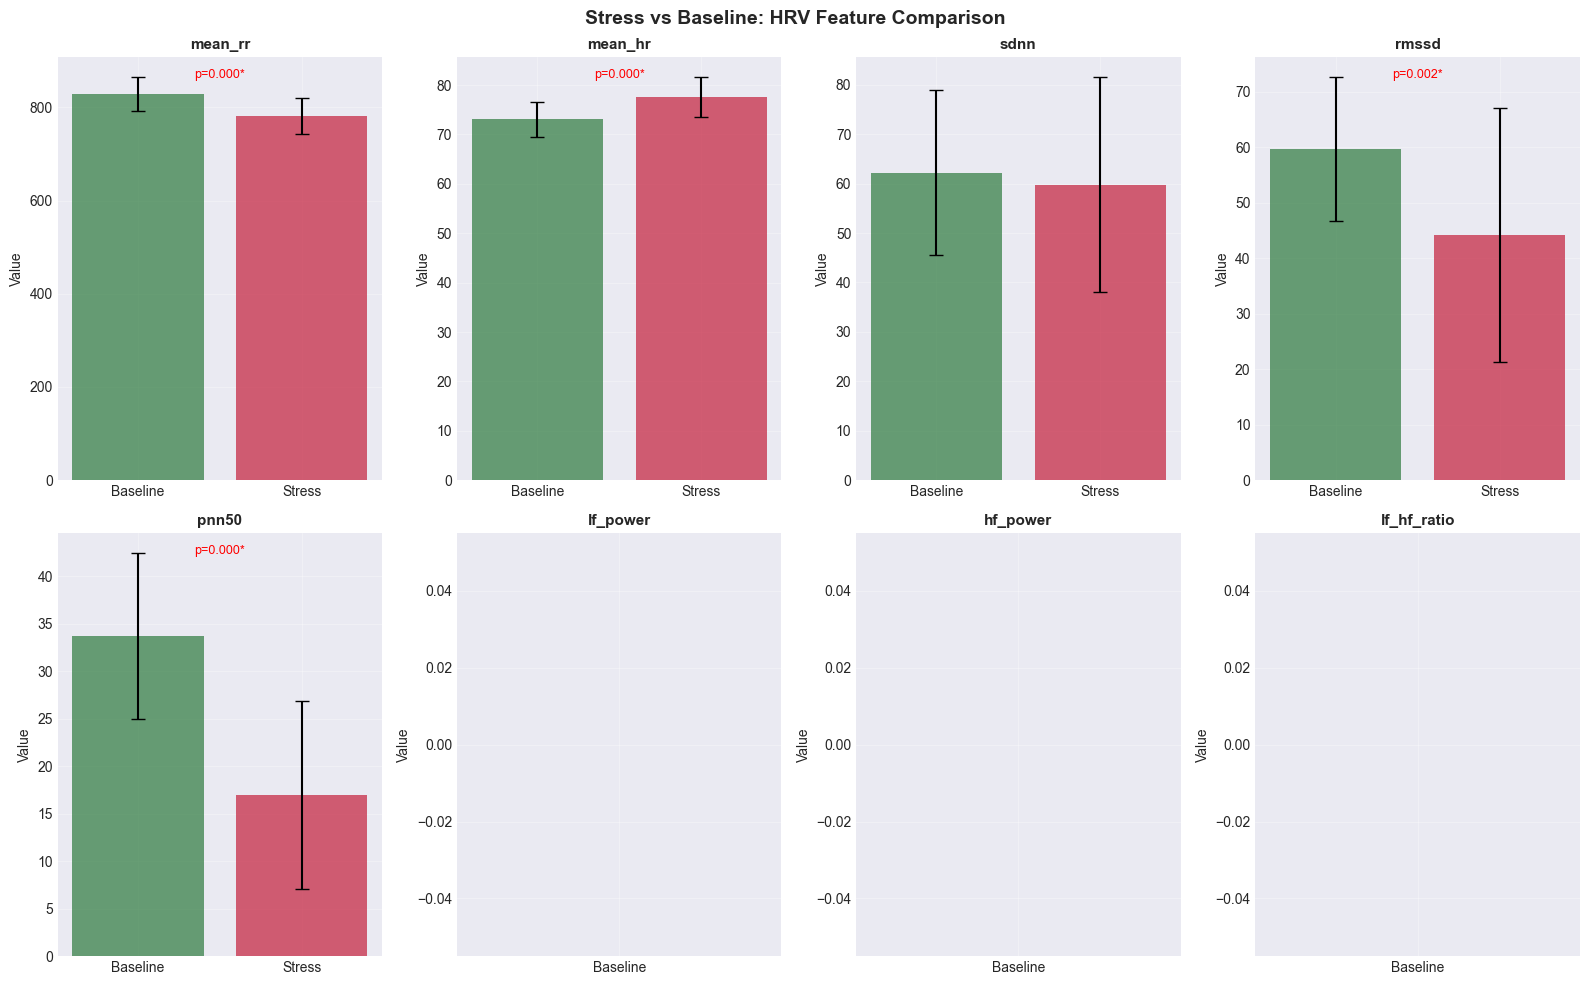

In [22]:

print("\n" + "="*60)
print("7. STRESS VS BASELINE COMPARISON")
print("="*60)

# Compare stress (label 2) vs baseline (label 1)
stress_df = features_by_condition.get(2, pd.DataFrame())
baseline_df = features_by_condition.get(1, pd.DataFrame())

if len(stress_df) > 0 and len(baseline_df) > 0:
    comparison_data = []
    
    for feature in feature_cols:
        baseline_mean = baseline_df[feature].mean()
        stress_mean = stress_df[feature].mean()
        
        # Calculate fold change
        fold_change = stress_mean / baseline_mean if baseline_mean != 0 else np.nan
        
        # Statistical test
        from scipy.stats import ttest_ind
        baseline_vals = baseline_df[feature].dropna()
        stress_vals = stress_df[feature].dropna()
        
        if len(baseline_vals) > 1 and len(stress_vals) > 1:
            t_stat, p_value = ttest_ind(baseline_vals, stress_vals)
        else:
            t_stat, p_value = np.nan, np.nan
        
        comparison_data.append({
            'Feature': feature,
            'Baseline Mean': baseline_mean,
            'Stress Mean': stress_mean,
            'Fold Change': fold_change,
            'p-value': p_value,
            'Significant': p_value < 0.05 if not np.isnan(p_value) else False
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df.round(4))
    
    # Plot comparison
    fig, axes = plt.subplots(2, 4, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, feature in enumerate(feature_cols):
        ax = axes[idx]
        
        # Get data
        baseline_vals = baseline_df[feature].dropna()
        stress_vals = stress_df[feature].dropna()
        
        # Create bar plot
        ax.bar(['Baseline', 'Stress'], 
              [baseline_vals.mean(), stress_vals.mean()],
              color=['#2d7a3e', '#c41e3a'], alpha=0.7)
        
        # Add error bars (std)
        ax.errorbar(['Baseline', 'Stress'], 
                   [baseline_vals.mean(), stress_vals.mean()],
                   yerr=[baseline_vals.std(), stress_vals.std()],
                   fmt='none', color='black', capsize=5)
        
        ax.set_title(feature, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        
        # Add p-value if significant
        p_val = comparison_df[comparison_df['Feature'] == feature]['p-value'].values[0]
        if not np.isnan(p_val) and p_val < 0.05:
            ax.text(0.5, 0.95, f'p={p_val:.3f}*', transform=ax.transAxes,
                   ha='center', fontsize=9, color='red')
    
    plt.suptitle('Stress vs Baseline: HRV Feature Comparison', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. RADAR PLOT FOR FEATURE COMPARISON


8. RADAR PLOT - Feature Profile Comparison


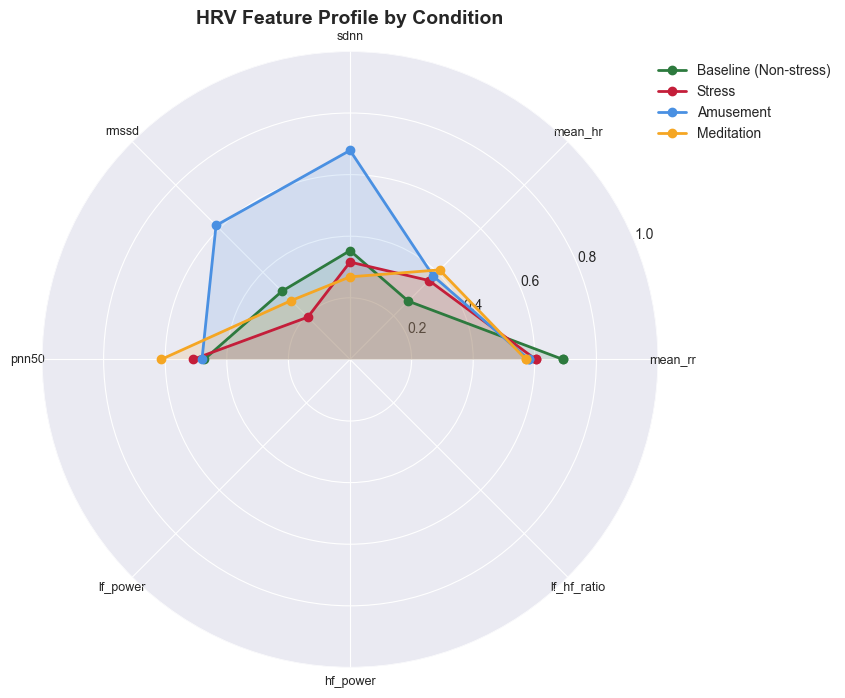

In [13]:

print("\n" + "="*60)
print("8. RADAR PLOT - Feature Profile Comparison")
print("="*60)

# Normalize features for radar plot
def normalize_features(df, feature_cols):
    """Normalize features to 0-1 range"""
    normalized = df[feature_cols].copy()
    for col in feature_cols:
        min_val = normalized[col].min()
        max_val = normalized[col].max()
        if max_val > min_val:
            normalized[col] = (normalized[col] - min_val) / (max_val - min_val)
    return normalized

# Get normalized features for each condition
normalized_features = {}
for label_id in [1, 2, 3, 4]:
    if label_id in features_by_condition and len(features_by_condition[label_id]) > 0:
        df_norm = normalize_features(features_by_condition[label_id], feature_cols)
        normalized_features[label_id] = df_norm.mean()

# Create radar plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

# Number of features
N = len(feature_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

for label_id in [1, 2, 3, 4]:
    if label_id in normalized_features:
        values = [normalized_features[label_id][feature] for feature in feature_cols]
        values += values[:1]  # Close the loop
        
        ax.plot(angles, values, 'o-', linewidth=2, 
                color=label_colors[label_id], label=label_names[label_id])
        ax.fill(angles, values, alpha=0.15, color=label_colors[label_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_cols, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('HRV Feature Profile by Condition', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)
plt.show()

## 9. PAIR PLOT FOR TOP FEATURES


9. PAIR PLOT - Top Feature Relationships
Top 4 discriminative features: ['mean_hr', 'sdnn', 'mean_rr', 'rmssd']
Color palette: {'Baseline (Non-stress)': '#2d7a3e', 'Stress': '#c41e3a', 'Amusement': '#4a90e2', 'Meditation': '#f5a623'}


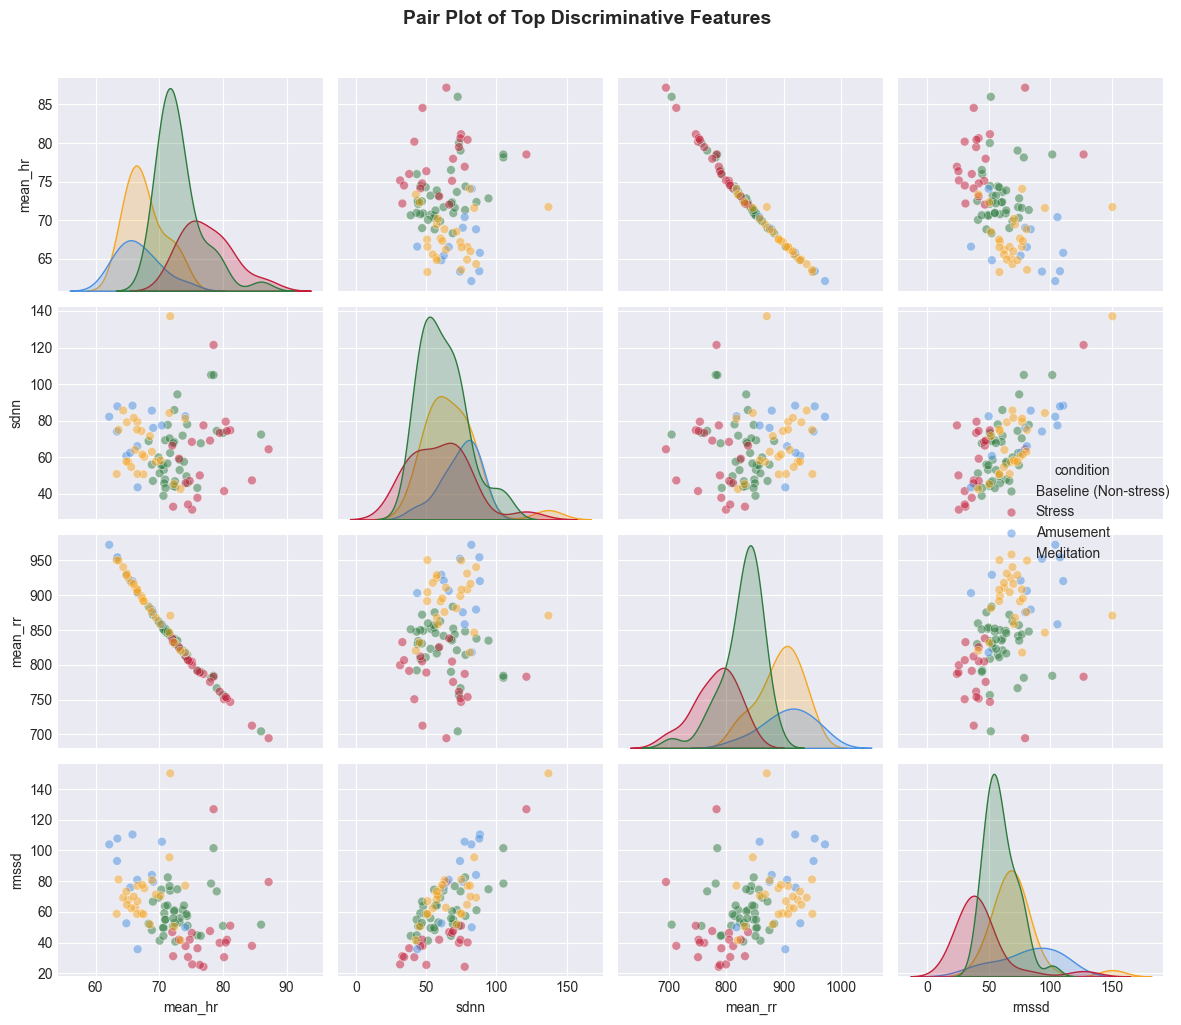

In [23]:
print("\n" + "="*60)
print("9. PAIR PLOT - Top Feature Relationships")
print("="*60)

# Select top 4 most discriminative features
if len(stress_df) > 0 and len(baseline_df) > 0:
    # Find most discriminative features (largest fold change)
    top_features = comparison_df.nlargest(4, 'Fold Change')['Feature'].tolist()
    
    print(f"Top 4 discriminative features: {top_features}")
    
    # Prepare data for pair plot
    pair_data = all_features_df[top_features + ['condition']].copy()
    
    # Create a color palette dictionary with condition names as keys
    color_palette = {label_names[label_id]: label_colors[label_id] 
                     for label_id in [1, 2, 3, 4] 
                     if label_id in features_by_condition and len(features_by_condition[label_id]) > 0}
    
    print(f"Color palette: {color_palette}")
    
    # Create pair plot with correct palette
    g = sns.pairplot(pair_data, 
                     vars=top_features, 
                     hue='condition', 
                     palette=color_palette,  # Now using condition names
                     diag_kind='kde',
                     plot_kws={'alpha': 0.5, 's': 40},
                     diag_kws={'fill': True})
    
    g.fig.suptitle('Pair Plot of Top Discriminative Features', 
                   fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 10. SAVE RESULTS

In [ ]:
print("\n" + "="*60)
print("10. SAVING RESULTS")
print("="*60)

# Create output directory
import os
output_dir = "../results/features"
os.makedirs(output_dir, exist_ok=True)

# Save feature DataFrames
for label_id, df in features_by_condition.items():
    if len(df) > 0:
        filename = f"features_{label_names[label_id].replace(' ', '_').replace('(', '').replace(')', '')}.csv"
        df.to_csv(os.path.join(output_dir, filename), index=False)
        print(f"✓ Saved: {filename}")

# Save combined features
all_features_df.to_csv(os.path.join(output_dir, "all_features.csv"), index=False)
print(f"✓ Saved: all_features.csv")

print(f"\n✅ All features saved to: {output_dir}")



10. SAVING RESULTS
✓ Saved: features_Baseline_Non-stress.csv
✓ Saved: features_Stress.csv
✓ Saved: features_Amusement.csv
✓ Saved: features_Meditation.csv
✓ Saved: all_features.csv

✅ All features saved to: ../results/features


## SUMMARY

In [18]:


print("\n" + "="*60)
print("FEATURE EXTRACTION SUMMARY")
print("="*60)

print(f"\n✅ Extracted features from {len(all_features_df)} ECG chunks")
print(f"✅ Features: {', '.join(feature_cols)}")
print(f"✅ Conditions analyzed: {', '.join([label_names[i] for i in [1, 2, 3, 4] if i in features_by_condition])}")

print("\n📊 Key Observations:")
for feature in feature_cols:
    if len(stress_df) > 0 and len(baseline_df) > 0:
        baseline_mean = baseline_df[feature].mean()
        stress_mean = stress_df[feature].mean()
        fold_change = stress_mean / baseline_mean if baseline_mean != 0 else np.nan
        print(f"  • {feature}: Stress {'↑' if fold_change > 1 else '↓'} {abs(fold_change):.2f}x vs Baseline")

print("\n✅ Feature extraction and visualization complete!")


FEATURE EXTRACTION SUMMARY

✅ Extracted features from 95 ECG chunks
✅ Features: mean_rr, mean_hr, sdnn, rmssd, pnn50, lf_power, hf_power, lf_hf_ratio
✅ Conditions analyzed: Baseline (Non-stress), Stress, Amusement, Meditation

📊 Key Observations:
  • mean_rr: Stress ↓ 0.94x vs Baseline
  • mean_hr: Stress ↑ 1.06x vs Baseline
  • sdnn: Stress ↓ 0.96x vs Baseline
  • rmssd: Stress ↓ 0.74x vs Baseline
  • pnn50: Stress ↓ 0.50x vs Baseline
  • lf_power: Stress ↓ nanx vs Baseline
  • hf_power: Stress ↓ nanx vs Baseline
  • lf_hf_ratio: Stress ↓ nanx vs Baseline

✅ Feature extraction and visualization complete!
